# Step 7: Model Evaluation


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join('..', 'Src')))

from evaluation.metrics import compute_all_metrics, compute_roc_curve, compute_precision_recall
from evaluation.calibration import compute_calibration_curve, compute_calibration_error, assess_calibration
from evaluation.stability_analysis import compute_metric_drift, stability_summary

PROCESSED_DIR = os.path.join('..', 'Data', 'Processed')
FIGURES_DIR = os.path.join('..', 'Reports', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print("Setup complete.")

Setup complete.


---
## 1. Load Predictions from Baseline Models

In [2]:
# Load predictions
pred_path = os.path.join(PROCESSED_DIR, 'baseline_predictions.csv')
predictions = pd.read_csv(pred_path, parse_dates=['date'])

print(f"Loaded predictions: {len(predictions):,} samples")
print(f"Date range: {predictions['date'].min().date()} to {predictions['date'].max().date()}")
print(f"Columns: {list(predictions.columns)}")

Loaded predictions: 1,564 samples
Date range: 2024-10-08 to 2026-01-07
Columns: ['date', 'ticker', 'target', 'lr_prob', 'dt_prob', 'rf_prob']


---
## 2. Compute Proper Metrics


In [3]:
y_true = predictions['target'].values

models = {
    'Logistic Regression': predictions['lr_prob'].values,
    'Decision Tree': predictions['dt_prob'].values,
    'Random Forest': predictions['rf_prob'].values
}

print("="*60)
print("COMPREHENSIVE METRICS")
print("="*60)
print(f"{'Model':<22} {'AUC':>8} {'Brier':>8} {'AvgPrec':>8} {'F1':>8}")
print("-"*60)

metrics_all = {}
for name, y_prob in models.items():
    m = compute_all_metrics(y_true, y_prob)
    metrics_all[name] = m
    print(f"{name:<22} {m['roc_auc']:>8.4f} {m['brier_score']:>8.4f} {m['avg_precision']:>8.4f} {m['f1']:>8.4f}")

print("="*60)
print("\nNote: Brier score closer to 0 is better. Random guess = 0.25")

COMPREHENSIVE METRICS
Model                       AUC    Brier  AvgPrec       F1
------------------------------------------------------------
Logistic Regression      0.5408   0.2487   0.5114   0.5013
Decision Tree            0.5215   0.2719   0.5008   0.5196
Random Forest            0.5584   0.2479   0.5195   0.5797

Note: Brier score closer to 0 is better. Random guess = 0.25


---
## 3. ROC Curves (Ranking Ability)

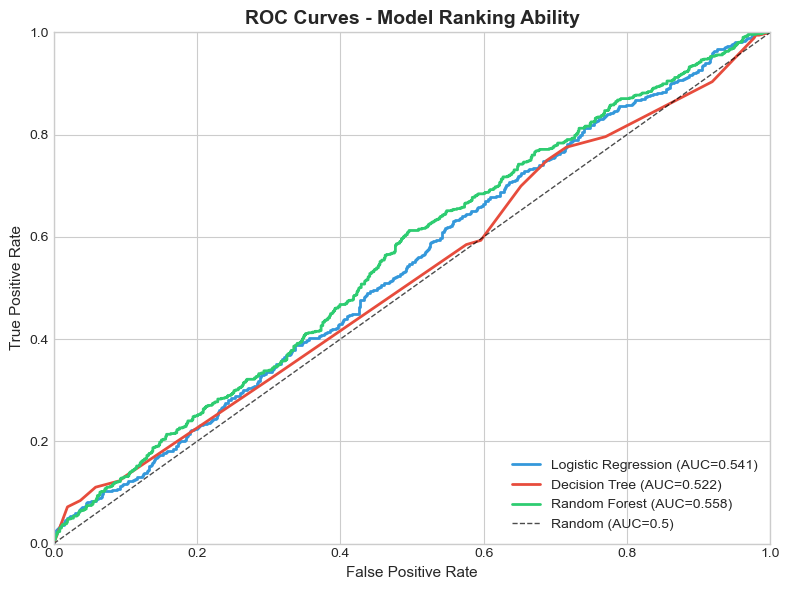

Saved: roc_curves.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71']
for (name, y_prob), color in zip(models.items(), colors):
    fpr, tpr, _ = compute_roc_curve(y_true, y_prob)
    auc = metrics_all[name]['roc_auc']
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.7, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves - Model Ranking Ability', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'roc_curves.png'), dpi=150)
plt.show()
print("Saved: roc_curves.png")

---
## 4. Calibration Curves (Probability Honesty)


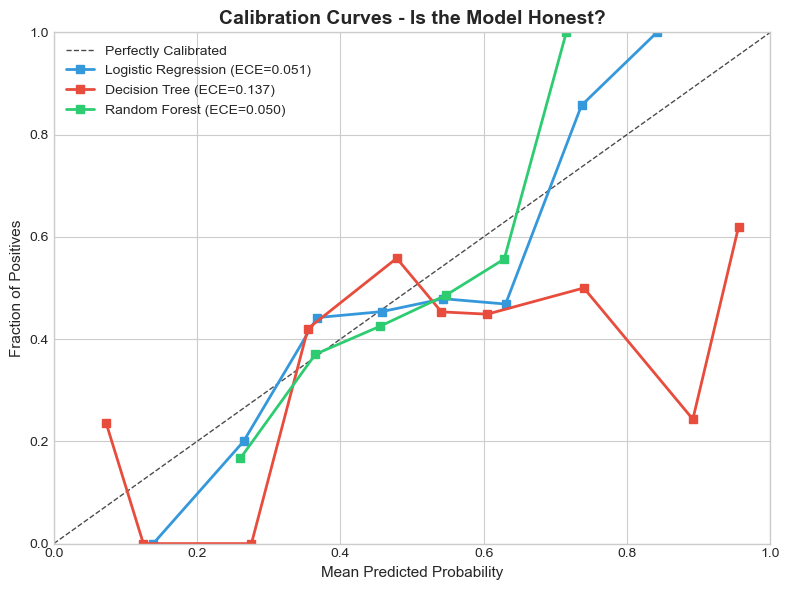

Saved: calibration_curves.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

# Perfect calibration line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.7, label='Perfectly Calibrated')

colors = ['#3498db', '#e74c3c', '#2ecc71']
for (name, y_prob), color in zip(models.items(), colors):
    prob_pred, prob_true = compute_calibration_curve(y_true, y_prob, n_bins=10)
    ece = compute_calibration_error(y_true, y_prob)
    ax.plot(prob_pred, prob_true, 's-', color=color, linewidth=2, markersize=6,
            label=f"{name} (ECE={ece:.3f})")

ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('Calibration Curves - Is the Model Honest?', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'calibration_curves.png'), dpi=150)
plt.show()
print("Saved: calibration_curves.png")

---
## 5. Calibration Assessment

In [6]:
print("="*60)
print("CALIBRATION ASSESSMENT")
print("="*60)
print(f"\nActual positive rate in test set: {np.mean(y_true)*100:.1f}%\n")

for name, y_prob in models.items():
    cal = assess_calibration(y_true, y_prob, name)
    print(f"{name}:")
    print(f"  Expected Calibration Error (ECE): {cal['ece']:.4f}")
    print(f"  Mean predicted probability: {cal['mean_predicted']*100:.1f}%")
    print(f"  Actual positive rate: {cal['actual_positive_rate']*100:.1f}%")
    diff = abs(cal['mean_predicted'] - cal['actual_positive_rate'])
    status = "GOOD" if diff < 0.05 else "NEEDS CALIBRATION" if diff < 0.1 else "POOR"
    print(f"  Calibration status: {status}")
    print()

CALIBRATION ASSESSMENT

Actual positive rate in test set: 46.4%

Logistic Regression:
  Expected Calibration Error (ECE): 0.0510
  Mean predicted probability: 49.9%
  Actual positive rate: 46.4%
  Calibration status: GOOD

Decision Tree:
  Expected Calibration Error (ECE): 0.1374
  Mean predicted probability: 53.3%
  Actual positive rate: 46.4%
  Calibration status: NEEDS CALIBRATION

Random Forest:
  Expected Calibration Error (ECE): 0.0500
  Mean predicted probability: 51.2%
  Actual positive rate: 46.4%
  Calibration status: GOOD



---
## 6. Precision-Recall Curves (Class Imbalance Reality)

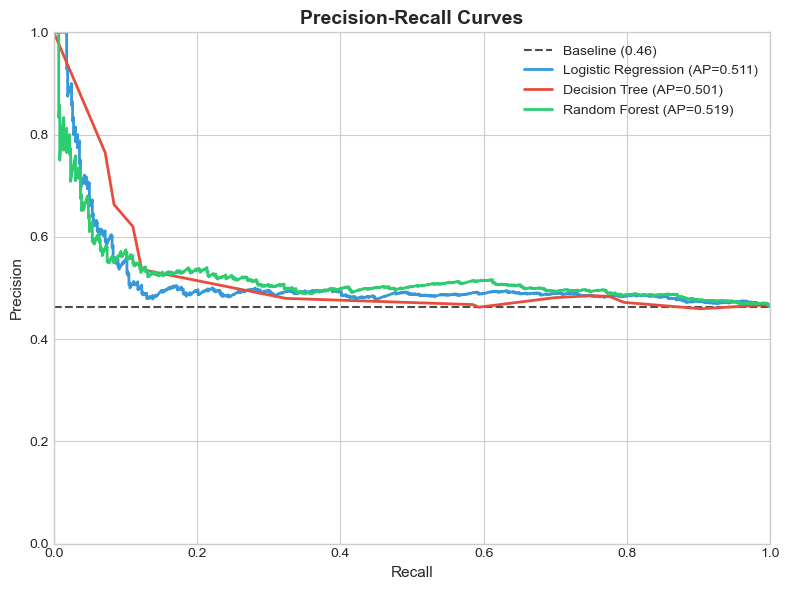

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

baseline = np.mean(y_true)
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.7, label=f'Baseline ({baseline:.2f})')

colors = ['#3498db', '#e74c3c', '#2ecc71']
for (name, y_prob), color in zip(models.items(), colors):
    precision, recall, _ = compute_precision_recall(y_true, y_prob)
    ap = metrics_all[name]['avg_precision']
    ax.plot(recall, precision, color=color, linewidth=2, label=f"{name} (AP={ap:.3f})")

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'precision_recall_curves.png'), dpi=150)
plt.show()

---
## 7. Temporal Stability (Metric Drift)

In [8]:
print("="*60)
print("TEMPORAL STABILITY ANALYSIS")
print("="*60)

for name, prob_col in [('Logistic Regression', 'lr_prob'), 
                        ('Decision Tree', 'dt_prob'), 
                        ('Random Forest', 'rf_prob')]:
    summary = stability_summary(predictions, 'target', prob_col, 'date')
    
    print(f"\n{name}:")
    if summary.get('status') == 'insufficient_data':
        print("  Insufficient data for analysis")
        continue
        
    print(f"  Mean AUC: {summary['mean_metric']:.4f}")
    print(f"  Std AUC:  {summary['std_metric']:.4f}")
    print(f"  Range:    [{summary['min_metric']:.4f}, {summary['max_metric']:.4f}]")
    print(f"  Trend:    {summary['trend'].upper()}")
    print(f"  Details:  {summary['details']}")

TEMPORAL STABILITY ANALYSIS

Logistic Regression:
  Mean AUC: 0.5752
  Std AUC:  0.0553
  Range:    [0.4998, 0.6658]
  Trend:    STABLE
  Details:  Earlier: 0.579, Recent: 0.570, Diff: 0.009

Decision Tree:
  Mean AUC: 0.5533
  Std AUC:  0.0842
  Range:    [0.4548, 0.6708]
  Trend:    DEGRADING
  Details:  Earlier: 0.590, Recent: 0.499, Diff: 0.090

Random Forest:
  Mean AUC: 0.5785
  Std AUC:  0.0855
  Range:    [0.4990, 0.7094]
  Trend:    DEGRADING
  Details:  Earlier: 0.628, Recent: 0.504, Diff: 0.124


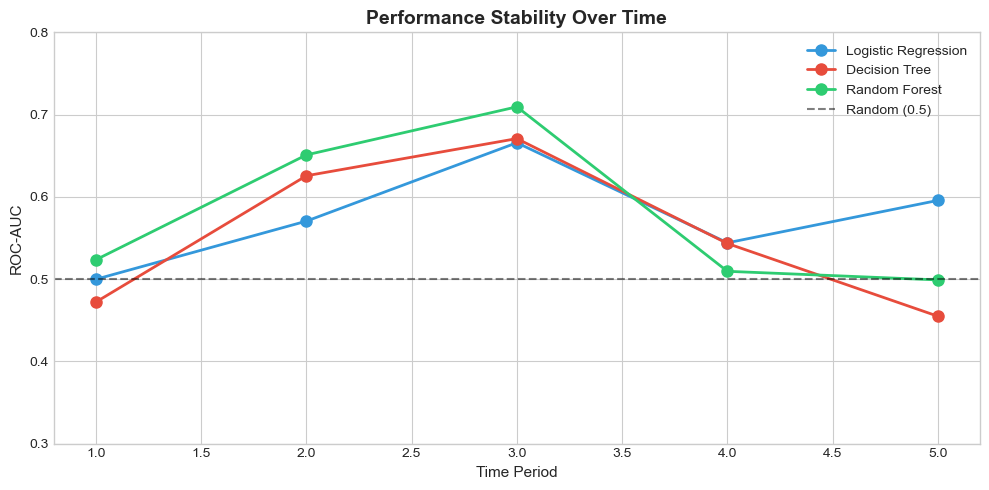

In [9]:
# Plot metric drift over time
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#3498db', '#e74c3c', '#2ecc71']
for (name, prob_col), color in zip([('Logistic Regression', 'lr_prob'), 
                                     ('Decision Tree', 'dt_prob'), 
                                     ('Random Forest', 'rf_prob')], colors):
    drift_df = compute_metric_drift(predictions, 'target', prob_col, 'date', n_periods=5)
    if len(drift_df) > 0:
        ax.plot(drift_df['period'], drift_df['metric'], 'o-', color=color, 
                linewidth=2, markersize=8, label=name)

ax.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Random (0.5)')
ax.set_xlabel('Time Period', fontsize=11)
ax.set_ylabel('ROC-AUC', fontsize=11)
ax.set_title('Performance Stability Over Time', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.set_ylim([0.3, 0.8])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'metric_drift.png'), dpi=150)
plt.show()

---
## 8. Final Assessment

In [10]:
print("\n" + "="*70)
print("MODEL TRUSTWORTHINESS CONCLUSION")
print("="*70)

for name, y_prob in models.items():
    m = metrics_all[name]
    ece = compute_calibration_error(y_true, y_prob)
    summary = stability_summary(predictions, 'target', 
                                'lr_prob' if 'Logistic' in name else 
                                'dt_prob' if 'Tree' in name else 'rf_prob')
    
    print(f"\n{name}:")
    print(f"  Ranking (AUC):     {m['roc_auc']:.3f}  {'✓' if m['roc_auc'] > 0.52 else '✗'}")
    print(f"  Probability (ECE): {ece:.3f}  {'✓' if ece < 0.05 else '~' if ece < 0.1 else '✗'}")
    print(f"  Stability:         {summary.get('std_metric', 0):.3f}  {'✓' if summary.get('std_metric', 1) < 0.05 else '~'}")
    
    # Overall verdict
    trustworthy = m['roc_auc'] > 0.52 and ece < 0.1
    print(f"  VERDICT: {'TRUSTWORTHY for position sizing' if trustworthy else 'USE WITH CAUTION'}")

print("\n" + "="*70)
print("\nKey Insight: A model with high AUC but poor calibration is DANGEROUS")
print("in finance because position sizing depends on probability quality.")
print("="*70)


MODEL TRUSTWORTHINESS CONCLUSION

Logistic Regression:
  Ranking (AUC):     0.541  ✓
  Probability (ECE): 0.051  ~
  Stability:         0.055  ~
  VERDICT: TRUSTWORTHY for position sizing

Decision Tree:
  Ranking (AUC):     0.522  ✓
  Probability (ECE): 0.137  ✗
  Stability:         0.084  ~
  VERDICT: USE WITH CAUTION

Random Forest:
  Ranking (AUC):     0.558  ✓
  Probability (ECE): 0.050  ~
  Stability:         0.085  ~
  VERDICT: TRUSTWORTHY for position sizing


Key Insight: A model with high AUC but poor calibration is DANGEROUS
in finance because position sizing depends on probability quality.
